**Topic - Skip Connection Impact Study on U-Net Segmentation Quality**

Image segmentation is a fundamental task in computer vision that involves classifying each pixel of an image into meaningful categories. Among various deep learning models, U-Net has emerged as a powerful architecture for segmentation tasks due to its encoder-decoder structure.

A key feature of U-Net is the use of skip connections, which transfer feature maps from the encoder to the decoder to preserve spatial information. These connections help overcome the loss of important details that occurs during downsampling.

U-net -> 1) Encoder - extract features , reduce size <br>
         2) Decoder - Incraese sizze, reconstruct image <br>
         3) Skip connections - connect encoder to decoder   

In [ ]:
!pip install segmentation-models-pytorch

import torch #DL library
import torch.nn as nn #Neural networks
import torchvision.transforms as transforms #Preprcoess images
from torch.utils.data import DataLoader #load dataset in bacthes
from torchvision.datasets import OxfordIIITPet #Datatset with segmantation
import segmentation_models_pytorch as smp #U-net model
import matplotlib.pyplot as plt

# Fix GPU errors
torch.backends.cudnn.enabled = False

**Dataset OxfordIITPet**

In [ ]:
transform_img = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor() # it Converts and also normalizes
])

transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.PILToTensor()  #Converts an image from PIL format to Tensor format
])

dataset = OxfordIIITPet(
    root='data',
    download=True,
    target_types='segmentation',
    transform=transform_img,
    target_transform=transform_mask
)

train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

Model 1 (WITHOUT Skip Connections)

Input -> Encoder -> Decoder -> Ouptut

In [ ]:
class SimpleSegNet(nn.Module):
    def __init__(self):
        super(SimpleSegNet, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), # 3 channels , 64 filetrs , 3 kernel size
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 3, 2, stride=2) #64 ->3
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model_no_skip = SimpleSegNet()

Model 2 (U-Net WITH Skip Connections)

In [ ]:
model_unet = smp.Unet(
    encoder_name="resnet18", # resnet18 -> DNN with 18 layers uses residual connections to imporve training
    encoder_weights=None,
    in_channels=3,
    classes=3
)

Loss + Optimizer

In [ ]:
device = 'cpu'
if device == 'cpu' and torch.cuda.is_available():
    print("WARNING: CUDA is available but forced to CPU. Temporarily disabling torch.cuda.is_available() to bypass CUDA checks.")
    _original_torch_cuda_is_available = torch.cuda.is_available
    torch.cuda.is_available = lambda: False

if device == 'cuda':
    torch.cuda.empty_cache()

model_no_skip.to(device)
model_unet.to(device)

criterion = nn.CrossEntropyLoss() #Loss calculate

optimizer1 = torch.optim.Adam(model_no_skip.parameters(), lr=0.001)
optimizer2 = torch.optim.Adam(model_unet.parameters(), lr=0.001)

Training

In [ ]:
epochs = 3

loss_no_skip_list = []
loss_unet_list = []

def train(model, optimizer):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        # Convert mask labels from [1,2,3] → [0,1,2] for CrossEntropy
        #Removes extra dimension
        masks = masks.squeeze(1).long().to(device) - 1

        optimizer.zero_grad()
        outputs = model(images)

        #comprae with actuak mask
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


print("Training WITHOUT Skip Connections")
for epoch in range(epochs):
    loss = train(model_no_skip, optimizer1)
    loss_no_skip_list.append(loss)
    print(f"Epoch {epoch+1}, Loss: {loss}")

print("\nTraining WITH Skip Connections (U-Net)")
for epoch in range(epochs):
    loss = train(model_unet, optimizer2)
    loss_unet_list.append(loss)
    print(f"Epoch {epoch+1}, Loss: {loss}")

Training WITHOUT Skip Connections
Epoch 1, Loss: 0.8964027881622314
Epoch 2, Loss: 0.8385803853040156
Epoch 3, Loss: 0.8127077740171681

Training WITH Skip Connections (U-Net)
Epoch 1, Loss: 0.6132187847533952
Epoch 2, Loss: 0.5026485860347748
Epoch 3, Loss: 0.457856906156825


DEMO

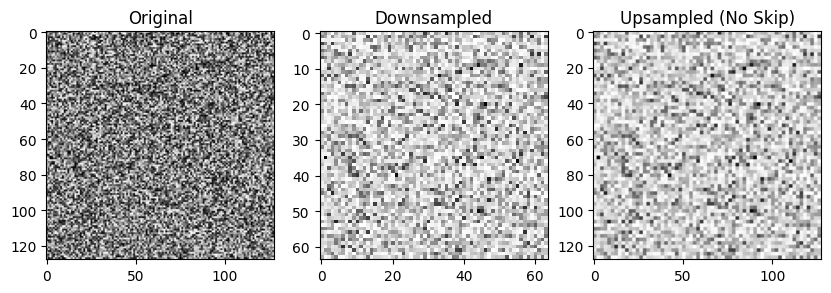

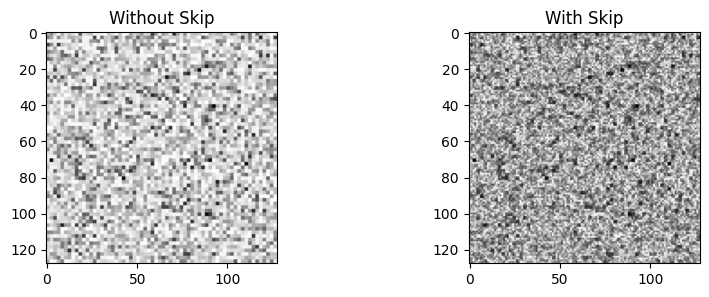

In [ ]:
image = torch.rand(1, 1, 128, 128) #Dummy images taken random

#Without skip

pooled = torch.nn.functional.max_pool2d(image, 2) #Downsampling where losses details
upsampled = torch.nn.functional.interpolate(pooled, scale_factor=2) #upsampled

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image[0][0], cmap='gray')

plt.subplot(1,3,2)
plt.title("Downsampled")
plt.imshow(pooled[0][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Upsampled (No Skip)")
plt.imshow(upsampled[0][0], cmap='gray')

plt.show()

skip_output = upsampled + image #WITH skip

plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.title("Without Skip")
plt.imshow(upsampled[0][0], cmap='gray')

plt.subplot(1,2,2)
plt.title("With Skip")
plt.imshow(skip_output[0][0], cmap='gray')

plt.show()

Loss graph

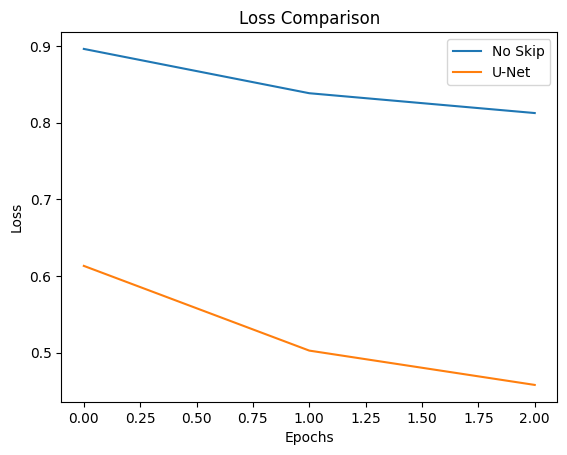

In [ ]:
plt.plot(loss_no_skip_list, label="No Skip")
plt.plot(loss_unet_list, label="U-Net")
plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Output Visualization

No Skip Connection Output


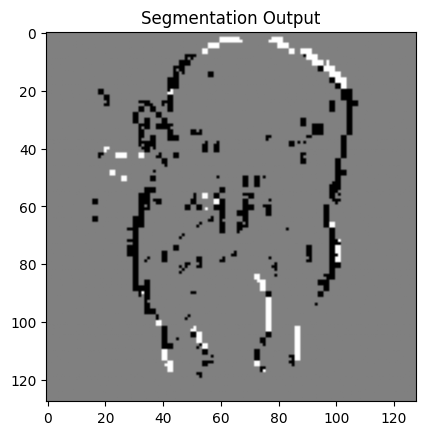

U-Net Output


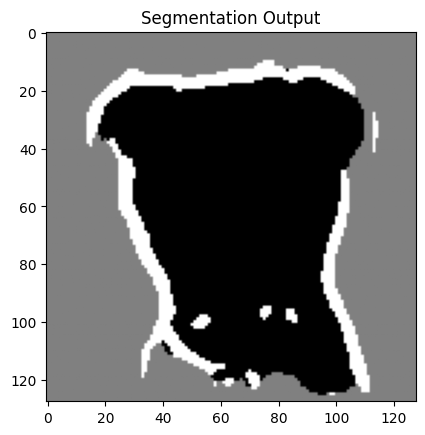

In [ ]:
def show_output(model):
    model.eval() #No dropout , No weight updates in short here we are testing
    images, _ = next(iter(train_loader)) #Takes one batch and we ignore mask
    images = images.to(device) #Sends images to CPU

    with torch.no_grad(): #no grad calculation
        outputs = model(images)  #Pixel → [0.2, 0.7, 0.1]

    pred = torch.argmax(outputs, dim=1) #highest value class

    plt.imshow(pred[0].cpu(), cmap='gray')
    plt.title("Segmentation Output")
    plt.show()

print("No Skip Connection Output")
show_output(model_no_skip)

print("U-Net Output")
show_output(model_unet)

**Conclusion**

This project analyzed the impact of skip connections in U-Net for image segmentation. By comparing models with and without skip connections, it was observed that skip connections significantly improve segmentation quality by preserving spatial information lost during downsampling. The U-Net model produced lower loss and more accurate, sharper outputs, demonstrating its effectiveness for segmentation tasks.